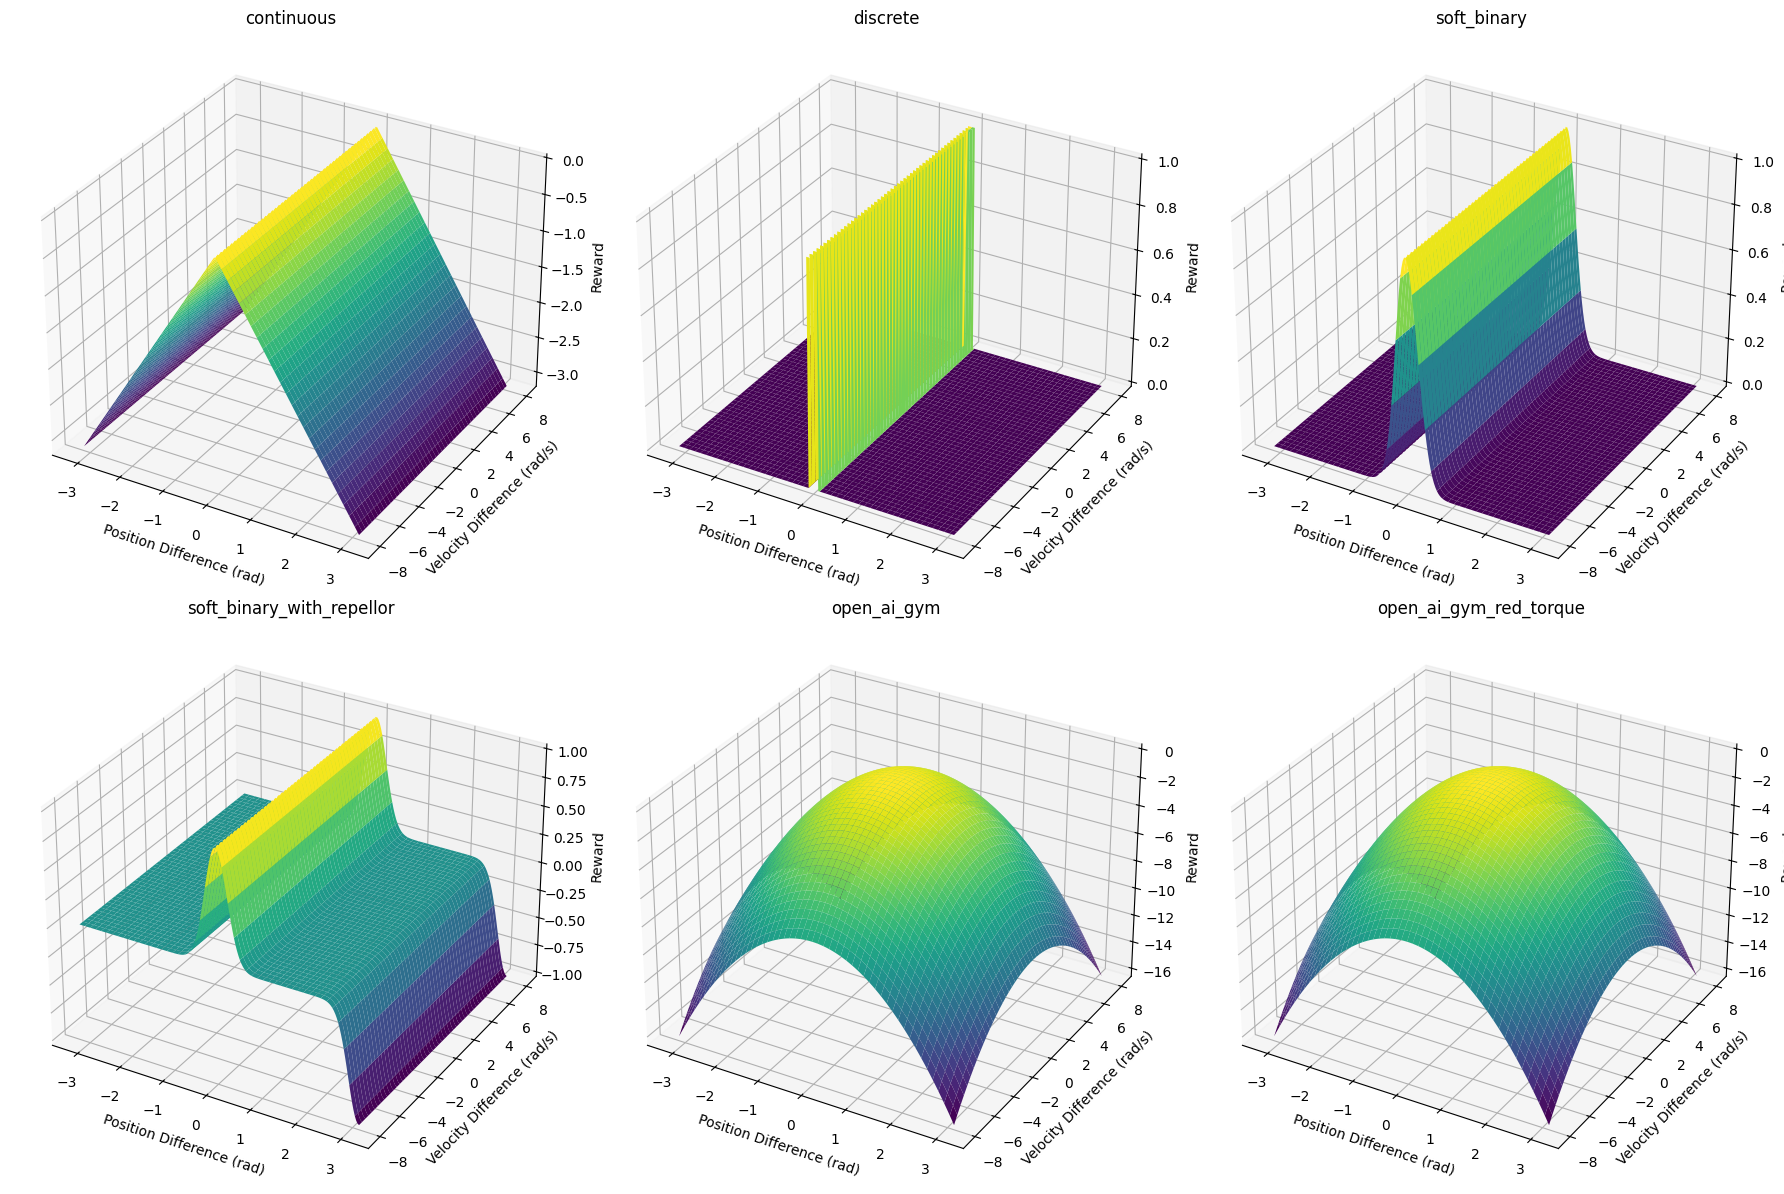

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Reward function definitions
def reward_continuous(pos_diff, vel_diff, action=0.0):
    return -np.abs(pos_diff)

def reward_discrete(pos_diff, vel_diff, action=0.0, epsilon=0.1):
    return (np.abs(pos_diff) < epsilon).astype(float)

def reward_soft_binary(pos_diff, vel_diff, action=0.0):
    return np.exp(-pos_diff**2 / (2 * 0.25**2))

def reward_soft_binary_with_repellor(pos_diff, vel_diff, action=0.0):
    attractor = np.exp(-pos_diff**2 / (2 * 0.25**2))
    repellor = np.exp(-np.abs(np.pi -pos_diff)**2 / (2 * 0.25**2))  # assume repellor at 0
    return attractor - repellor

def reward_open_ai_gym(pos_diff, vel_diff, action=0.0):
    return -(pos_diff)**2 - 0.1 * (vel_diff)**2 - 0.001 * action**2

def reward_open_ai_gym_red_torque(pos_diff, vel_diff, action=0.0):
    return -(pos_diff)**2 - 0.1 * (vel_diff)**2 - 0.01 * action**2

# Set up grid
pos_range = np.linspace(-np.pi, np.pi, 200)
vel_range = np.linspace(-8.0, 8.0, 200)
pos_diff, vel_diff = np.meshgrid(pos_range, vel_range)

# Compute all rewards
rewards = {
    "continuous": reward_continuous(pos_diff, vel_diff),
    "discrete": reward_discrete(pos_diff, vel_diff),
    "soft_binary": reward_soft_binary(pos_diff, vel_diff),
    "soft_binary_with_repellor": reward_soft_binary_with_repellor(pos_diff, vel_diff),
    "open_ai_gym": reward_open_ai_gym(pos_diff, vel_diff),
    "open_ai_gym_red_torque": reward_open_ai_gym_red_torque(pos_diff, vel_diff),
}

# Plot all in subplots
fig = plt.figure(figsize=(18, 12))
for i, (name, reward_grid) in enumerate(rewards.items(), 1):
    ax = fig.add_subplot(2, 3, i, projection='3d')
    ax.plot_surface(pos_diff, vel_diff, reward_grid, cmap='viridis')
    ax.set_title(name)
    ax.set_xlabel('Position Difference (rad)')
    ax.set_ylabel('Velocity Difference (rad/s)')
    ax.set_zlabel('Reward')

plt.tight_layout()
plt.show()

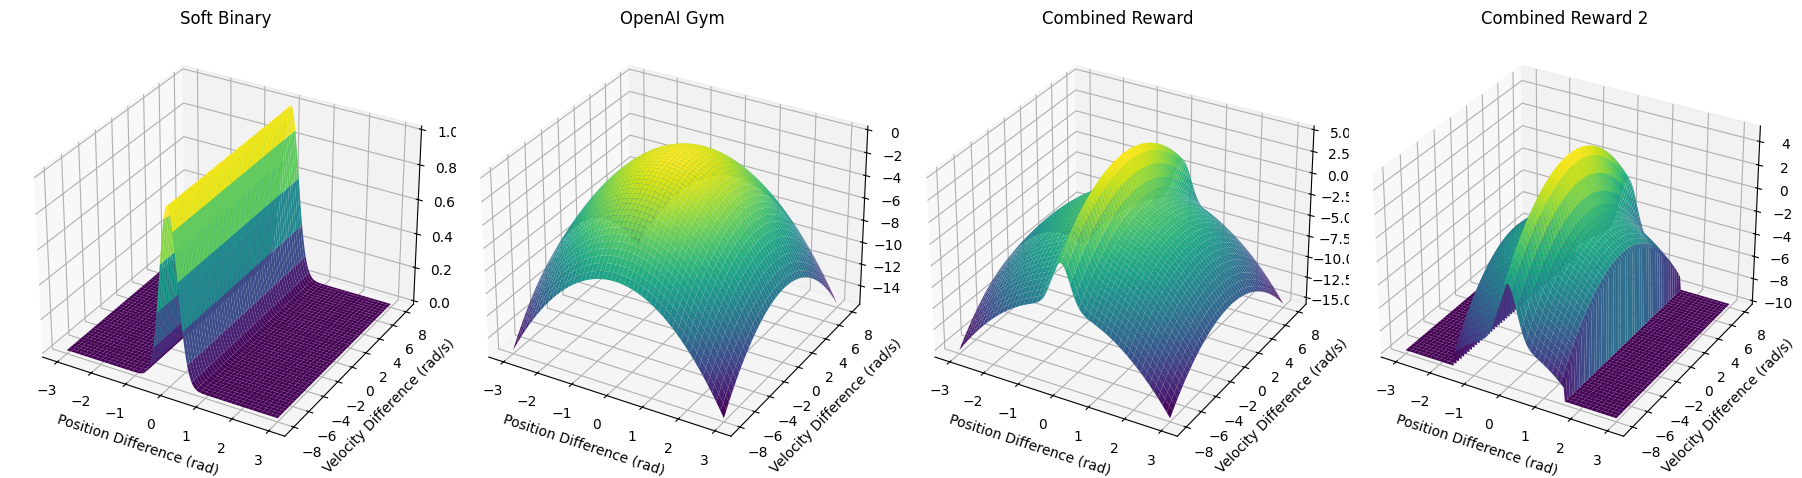

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define reward functions
def soft_binary(pos_diff, vel_diff, action=0.0):
    return np.exp(-pos_diff**2 / (2 * 0.25**2))

def open_ai_gym(pos_diff, vel_diff, action=0.0):
    return (-(pos_diff)**2.0 - 0.1*(vel_diff)**2.0 - 0.001*action**2.0)

def combined_reward(pos_diff, vel_diff, action=0.0):
    return open_ai_gym(pos_diff, vel_diff, action) + 5 * soft_binary(pos_diff, vel_diff, action)

def combined_reward2(pos_diff, vel_diff, action=0.0):
    rew = (open_ai_gym(pos_diff, vel_diff, action) + 5 * soft_binary(pos_diff, vel_diff, action)) * (abs(pos_diff)< np.pi/2) + (abs(pos_diff)>= np.pi/2) * -10
    return rew

# Create a grid of position and velocity differences
pos_range = np.linspace(-3.0, 3.0, 200)
vel_range = np.linspace(-8.0, 8.0, 200)
pos_diff, vel_diff = np.meshgrid(pos_range, vel_range)

# Compute reward grids
soft_binary_grid = soft_binary(pos_diff, vel_diff)
open_ai_gym_grid = open_ai_gym(pos_diff, vel_diff)
combined_grid = combined_reward(pos_diff, vel_diff)
combined_grid2 = combined_reward2(pos_diff, vel_diff)

# Plot all three reward functions
fig, axes = plt.subplots(1, 4, figsize=(18, 6), subplot_kw={'projection': '3d'})

titles = ['Soft Binary', 'OpenAI Gym', 'Combined Reward', 'Combined Reward 2']
grids = [soft_binary_grid, open_ai_gym_grid, combined_grid, combined_grid2]

for ax, title, grid in zip(axes, titles, grids):
    ax.plot_surface(pos_diff, vel_diff, grid, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel("Position Difference (rad)")
    ax.set_ylabel("Velocity Difference (rad/s)")
    ax.set_zlabel("Reward")

plt.tight_layout()
plt.show()